In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.1 MB/s eta 0:00:00


In [2]:
!unzip -q /content/data_CAT_vs_HAW.zip -d /content/
!ls /content/data_CAT_vs_HAW

classes.txt  images  labels  notes.json


In [3]:
import random
import shutil
from pathlib import Path

DATA_DIR = Path("/content/data_CAT_vs_HAW")

images_dir = DATA_DIR / "images"
labels_dir = DATA_DIR / "labels"

output_dir = DATA_DIR / "yolo_split"

# Delete old split if it exists
if output_dir.exists():
    shutil.rmtree(output_dir)

# Create folders
for split in ["train", "test"]:
    (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

images = [
    p for p in images_dir.iterdir()
    if p.suffix.lower() in image_exts
]

random.seed(42)
random.shuffle(images)

train_size = int(len(images) * 0.8)

train_images = images[:train_size]
test_images = images[train_size:]

def copy_data(image_list, split):
    missing_labels = 0

    for img_path in image_list:
        label_path = labels_dir / f"{img_path.stem}.txt"

        shutil.copy2(img_path, output_dir / "images" / split / img_path.name)

        if label_path.exists():
            shutil.copy2(label_path, output_dir / "labels" / split / label_path.name)
        else:
            missing_labels += 1
            print(f"Missing label: {img_path.name}")

    return missing_labels

missing_train = copy_data(train_images, "train")
missing_test = copy_data(test_images, "test")

print("Split complete")
print(f"Total images: {len(images)}")
print(f"Train images: {len(train_images)}")
print(f"Test images: {len(test_images)}")
print(f"Missing train labels: {missing_train}")
print(f"Missing test labels: {missing_test}")

Split complete
Total images: 176
Train images: 140
Test images: 36
Missing train labels: 0
Missing test labels: 0


In [4]:
from pathlib import Path
from collections import Counter

label_dir = Path("/content/data_CAT_vs_HAW/labels")
counts = Counter()

for txt in label_dir.glob("*.txt"):
    text = txt.read_text().strip()
    if not text:
        continue

    for line in text.splitlines():
        cls_id = int(float(line.split()[0]))
        counts[cls_id] += 1

print("Class ID counts:", counts)

Class ID counts: Counter({1: 428, 2: 416, 4: 147, 3: 114, 0: 29})


In [12]:
yaml_text = """
path: /content/data_CAT_vs_HAW/yolo_split
train: images/train
val: images/test
test: images/test

names:
  0: BALL
  1: CAT
  2: HAW
  3: POST
  4: REF
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_text)

print(open("/content/data.yaml").read())


path: /content/data_CAT_vs_HAW/yolo_split
train: images/train
val: images/test
test: images/test

names:
  0: BALL
  1: CAT
  2: HAW
  3: POST
  4: REF



In [13]:
!echo "Train images:"
!find /content/data_CAT_vs_HAW/yolo_split/images/train -type f | wc -l

!echo "Test images:"
!find /content/data_CAT_vs_HAW/yolo_split/images/test -type f | wc -l

!echo "Train labels:"
!find /content/data_CAT_vs_HAW/yolo_split/labels/train -type f | wc -l

!echo "Test labels:"
!find /content/data_CAT_vs_HAW/yolo_split/labels/test -type f | wc -l

Train images:
140
Test images:
36
Train labels:
140
Test labels:
36


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e708417f1d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        


0: 384x640 5 CATs, 3 HAWs, 3 REFs, 10.6ms
1: 384x640 7 CATs, 6 HAWs, 2 REFs, 10.6ms
2: 384x640 3 CATs, 5 POSTs, 1 REF, 10.6ms
3: 384x640 5 CATs, 2 HAWs, 3 POSTs, 6 REFs, 10.6ms
4: 384x640 3 CATs, 2 HAWs, 2 REFs, 10.6ms
Speed: 2.4ms preprocess, 10.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
Predictions saved to: /content/runs/detect/predict


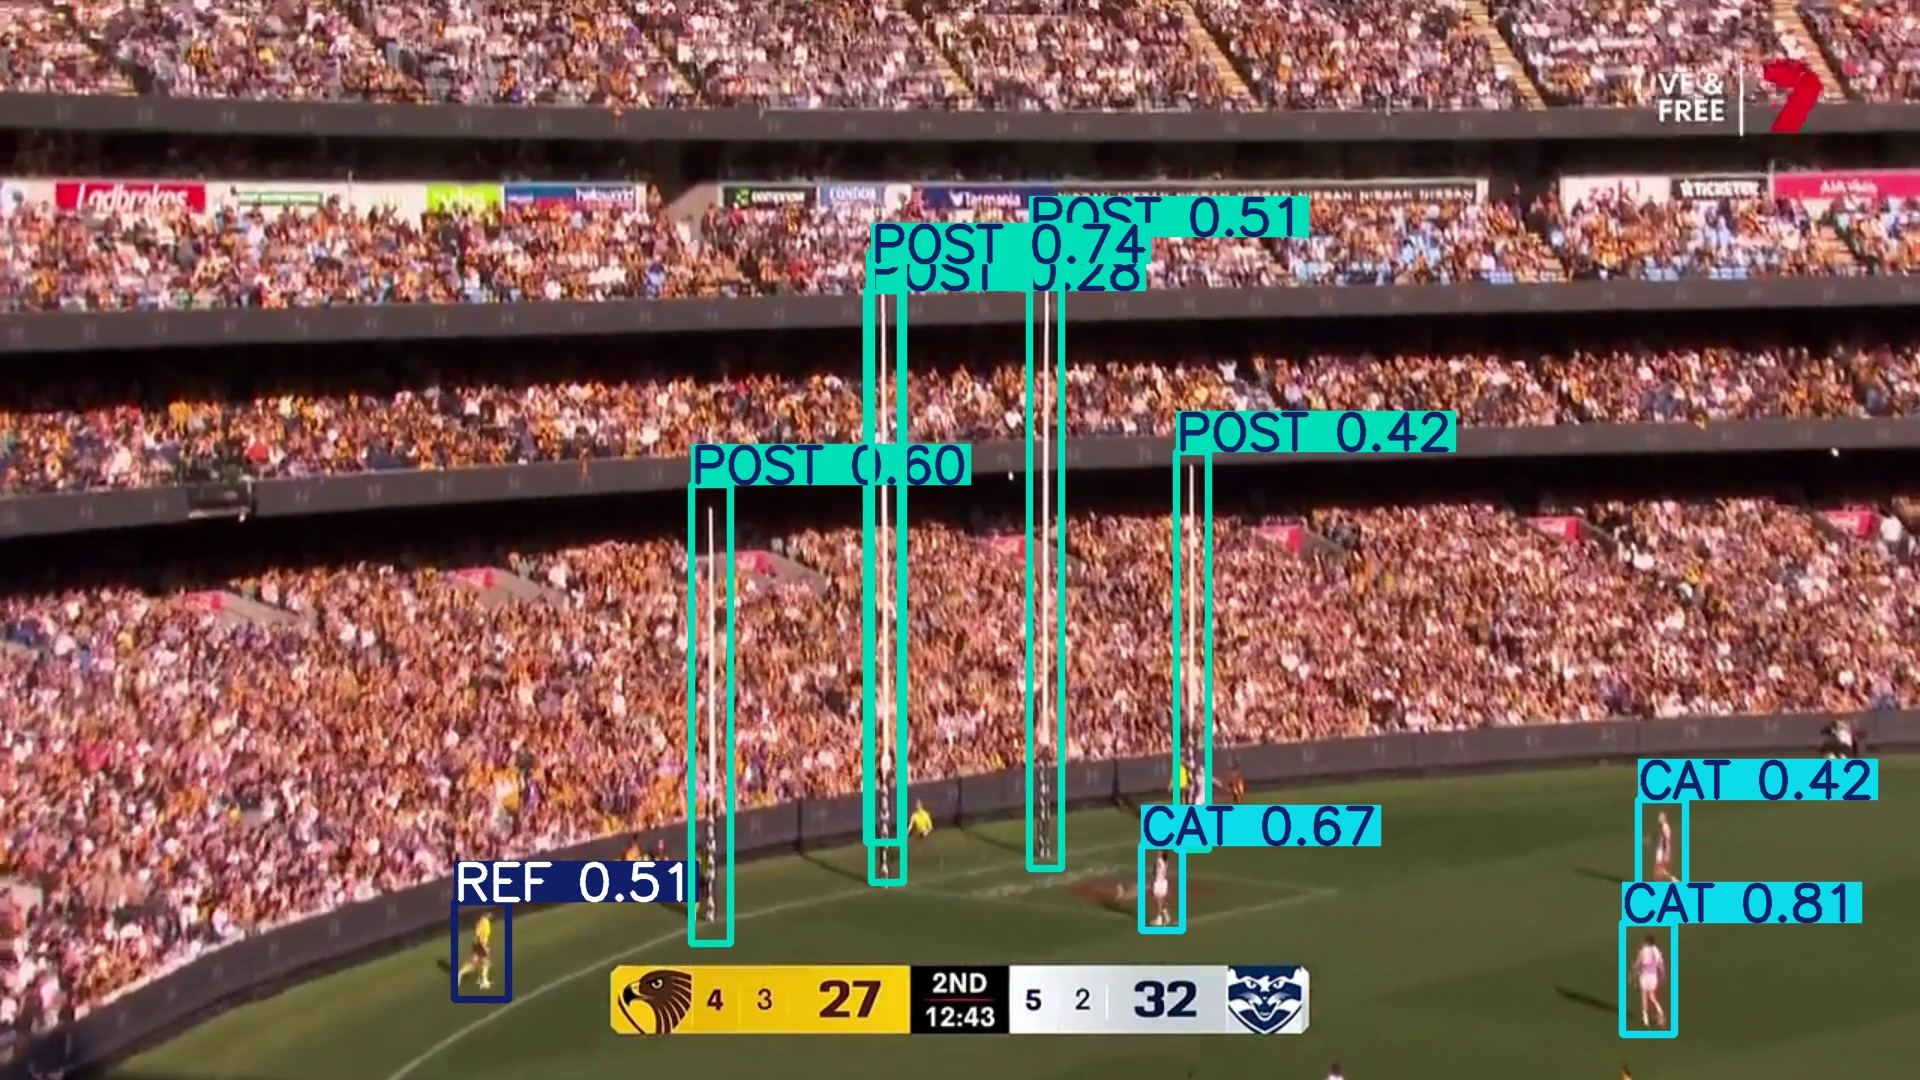

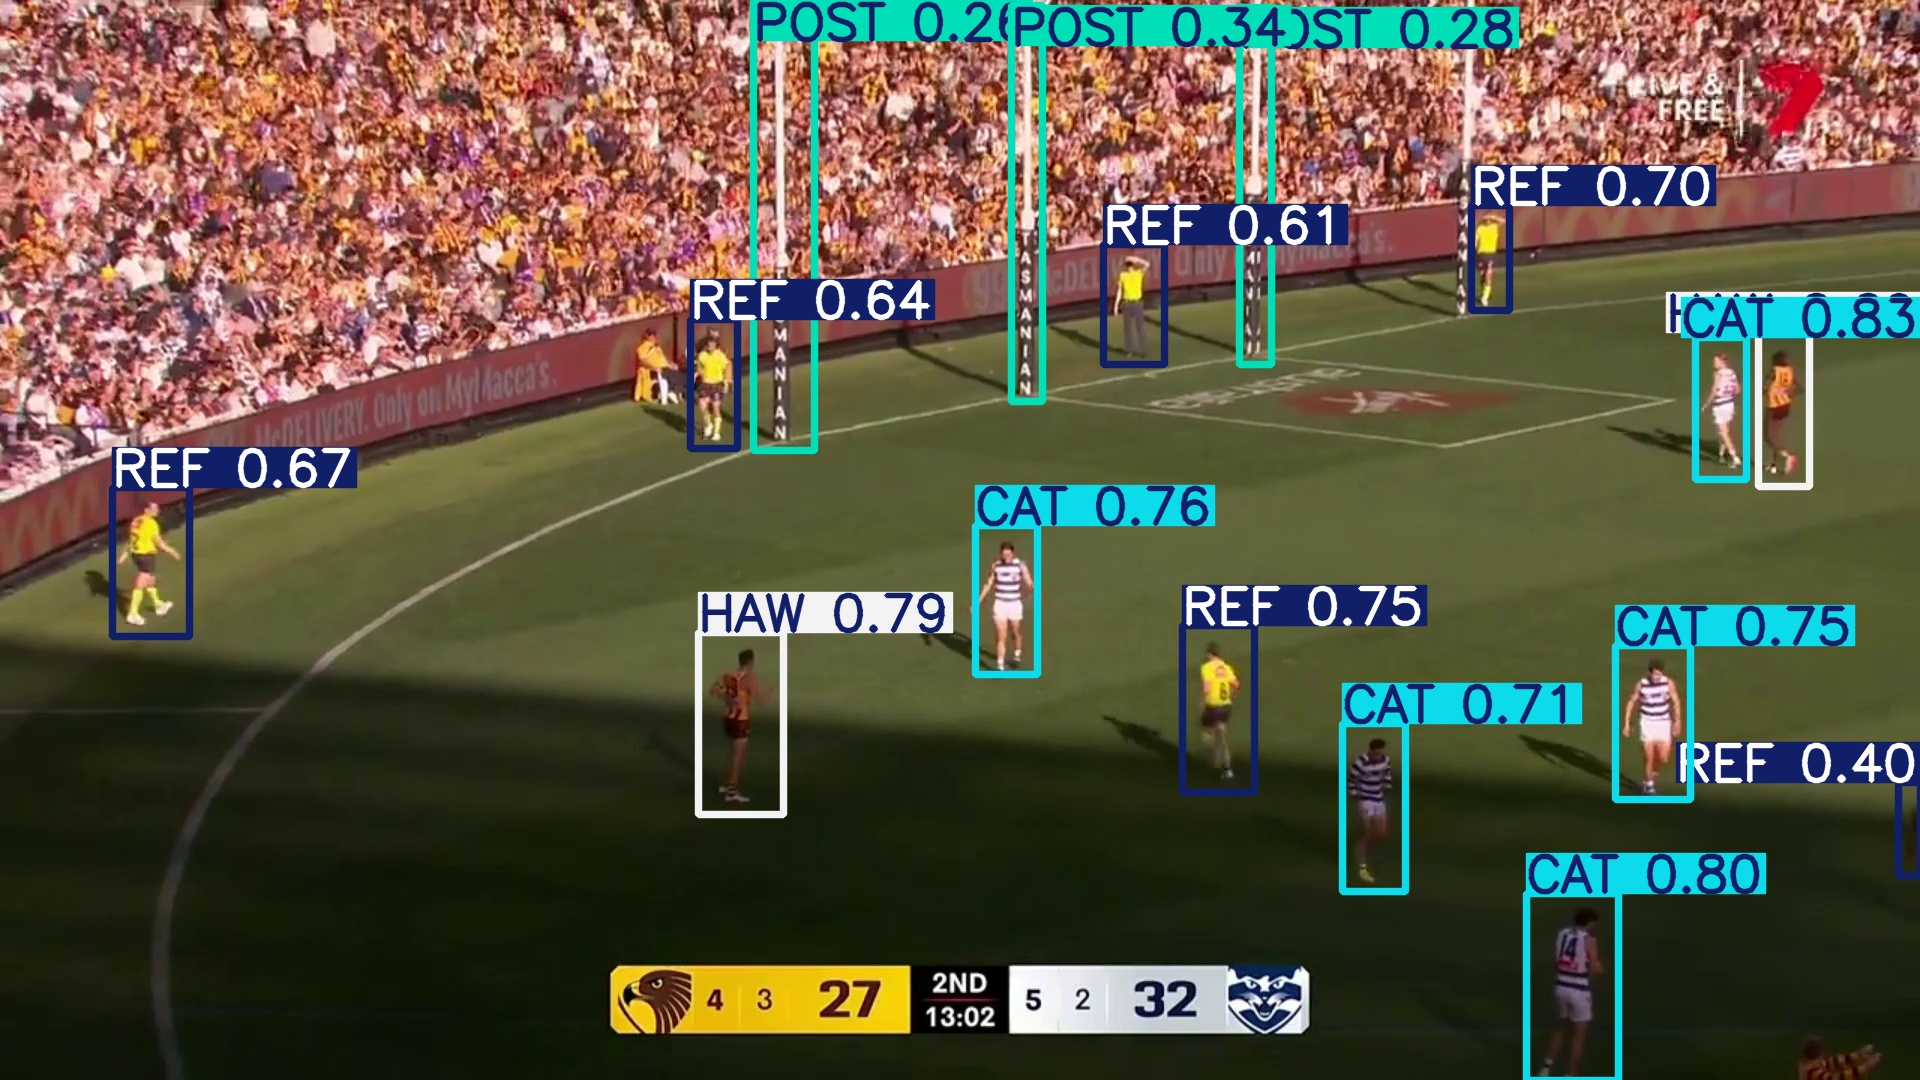

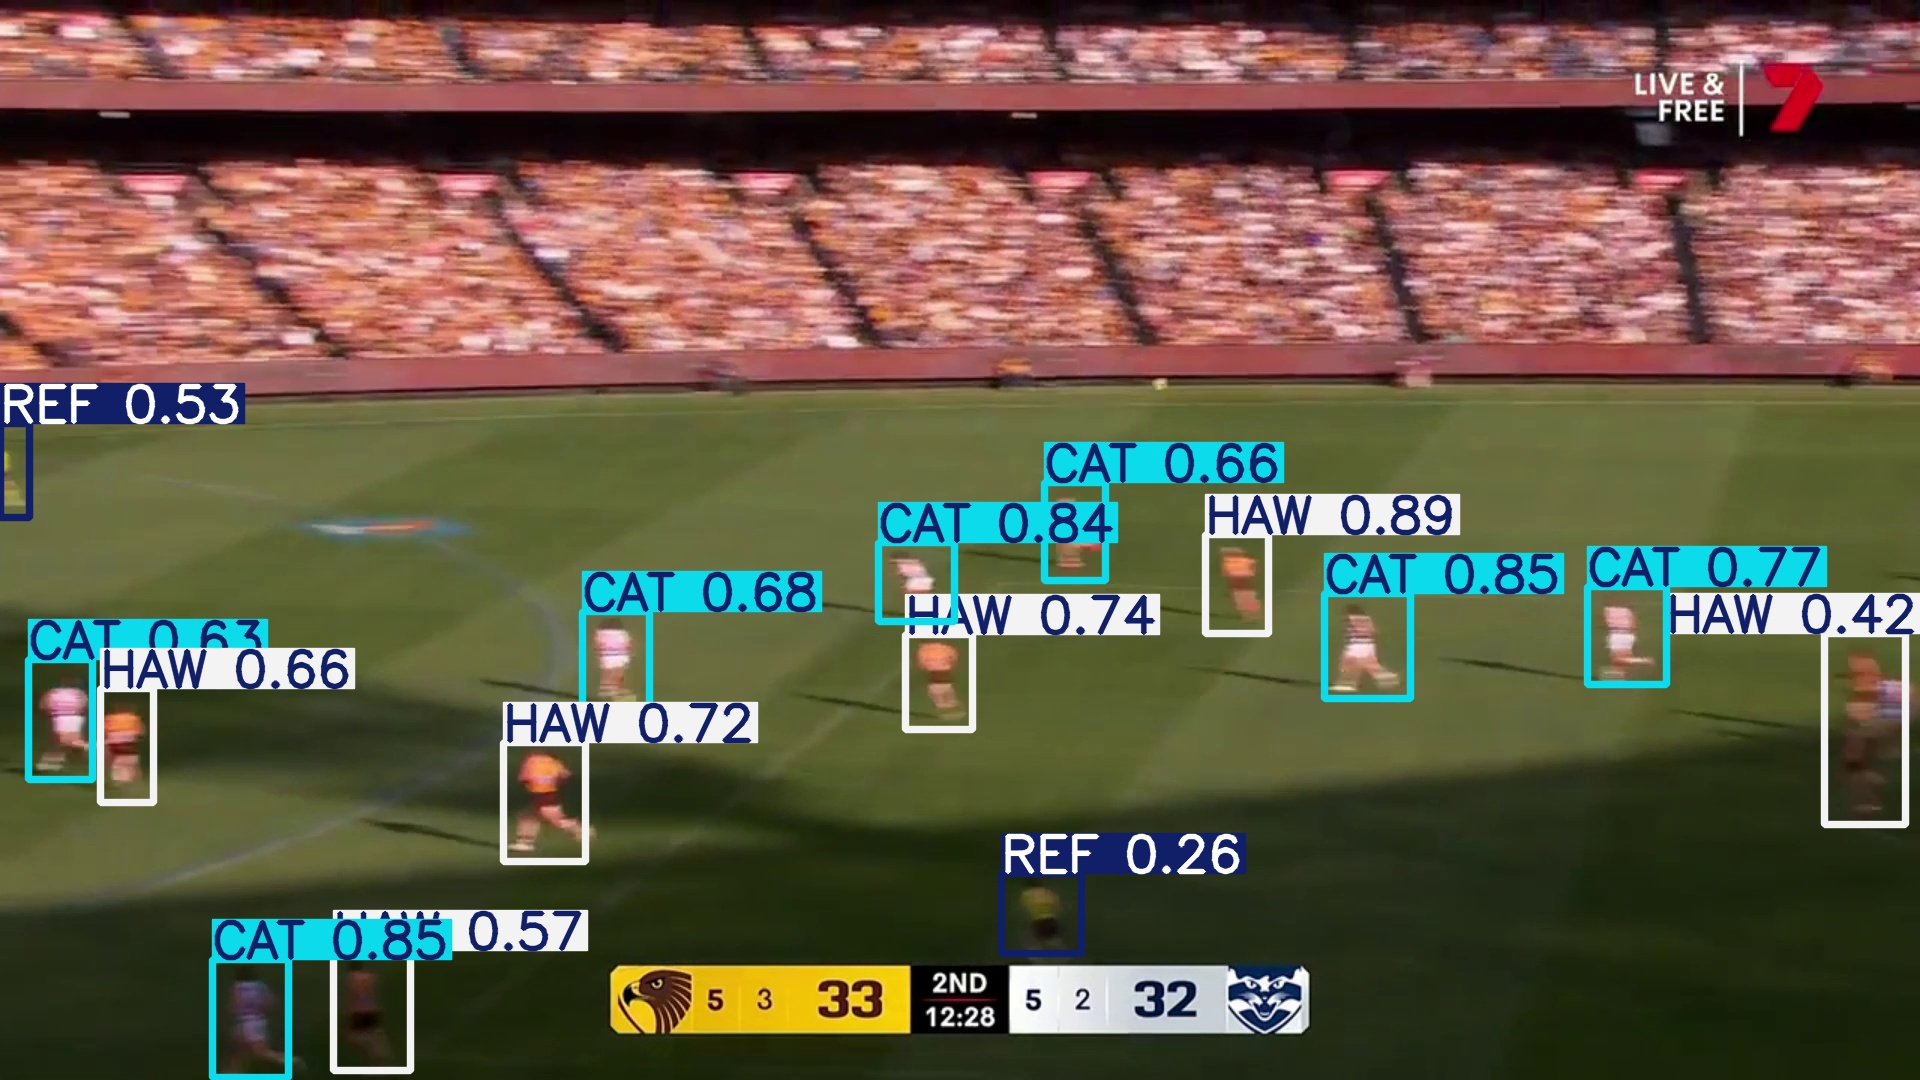

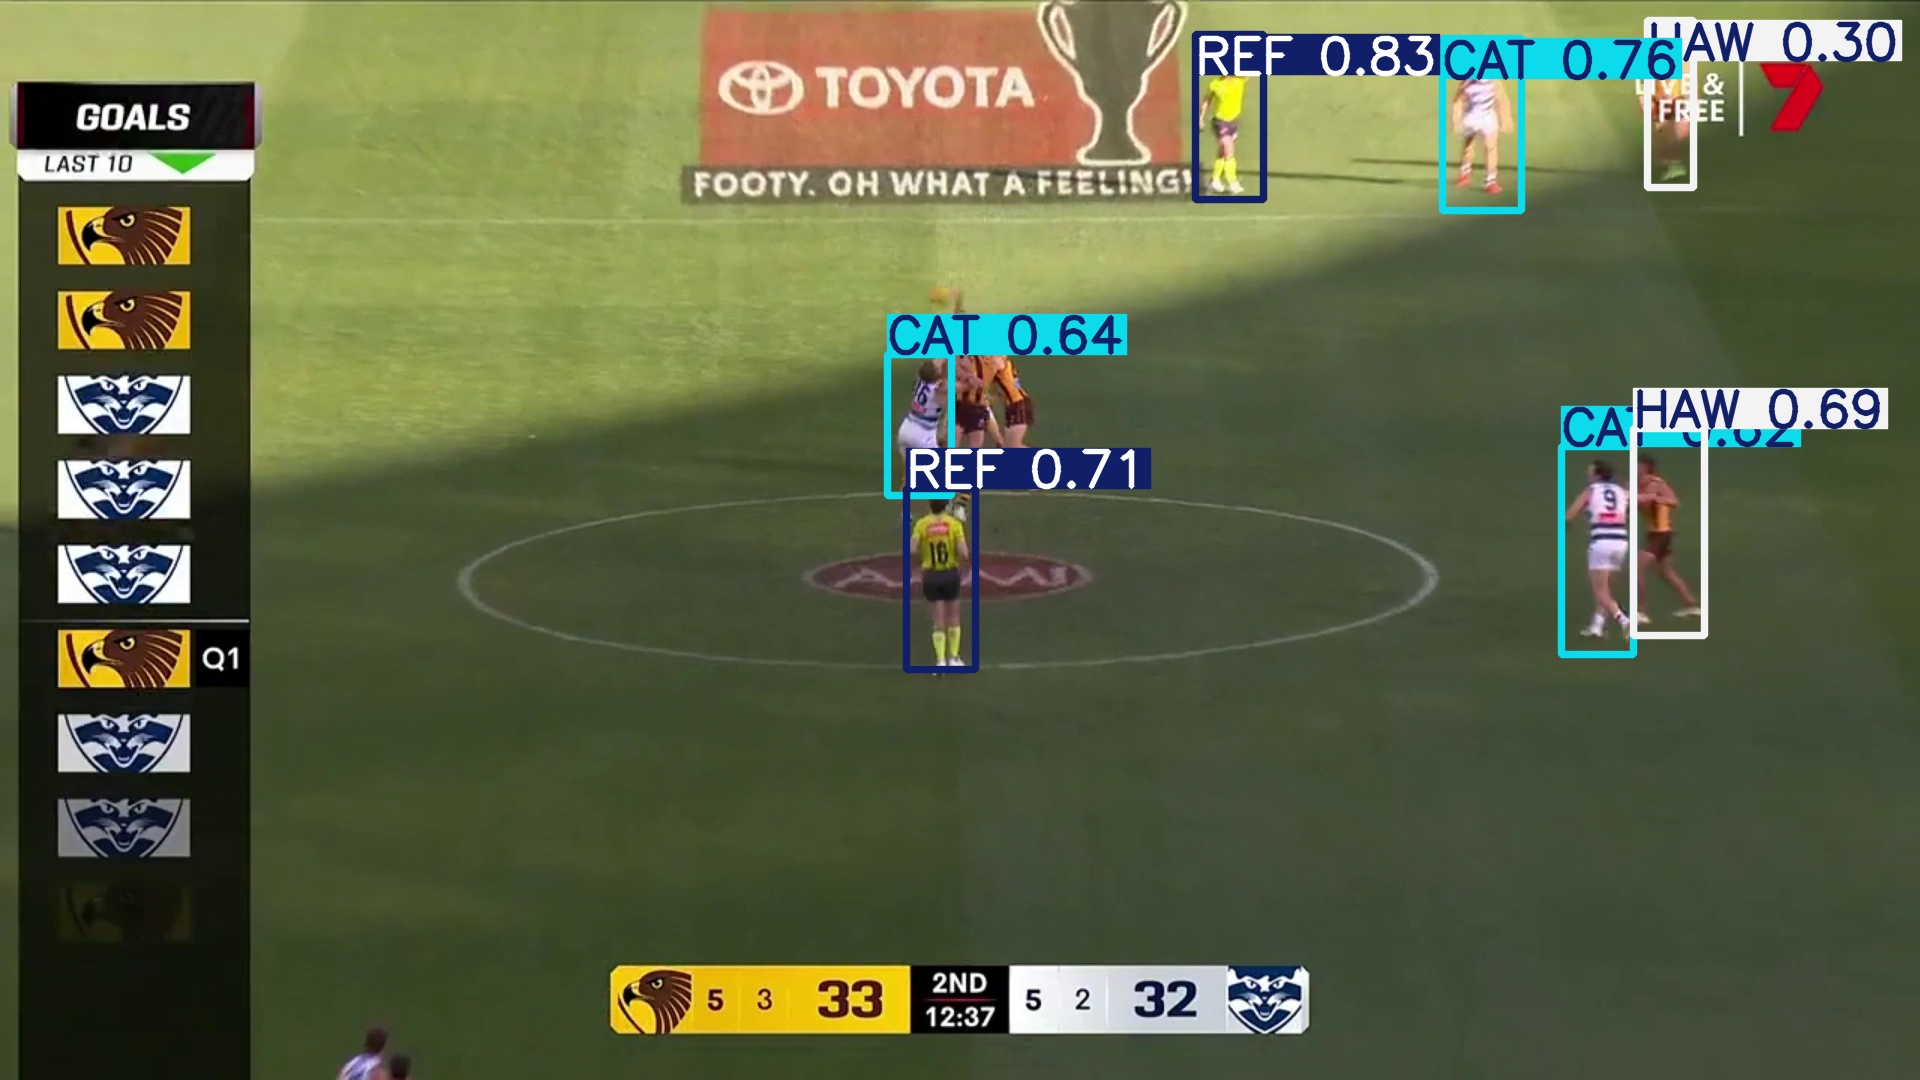

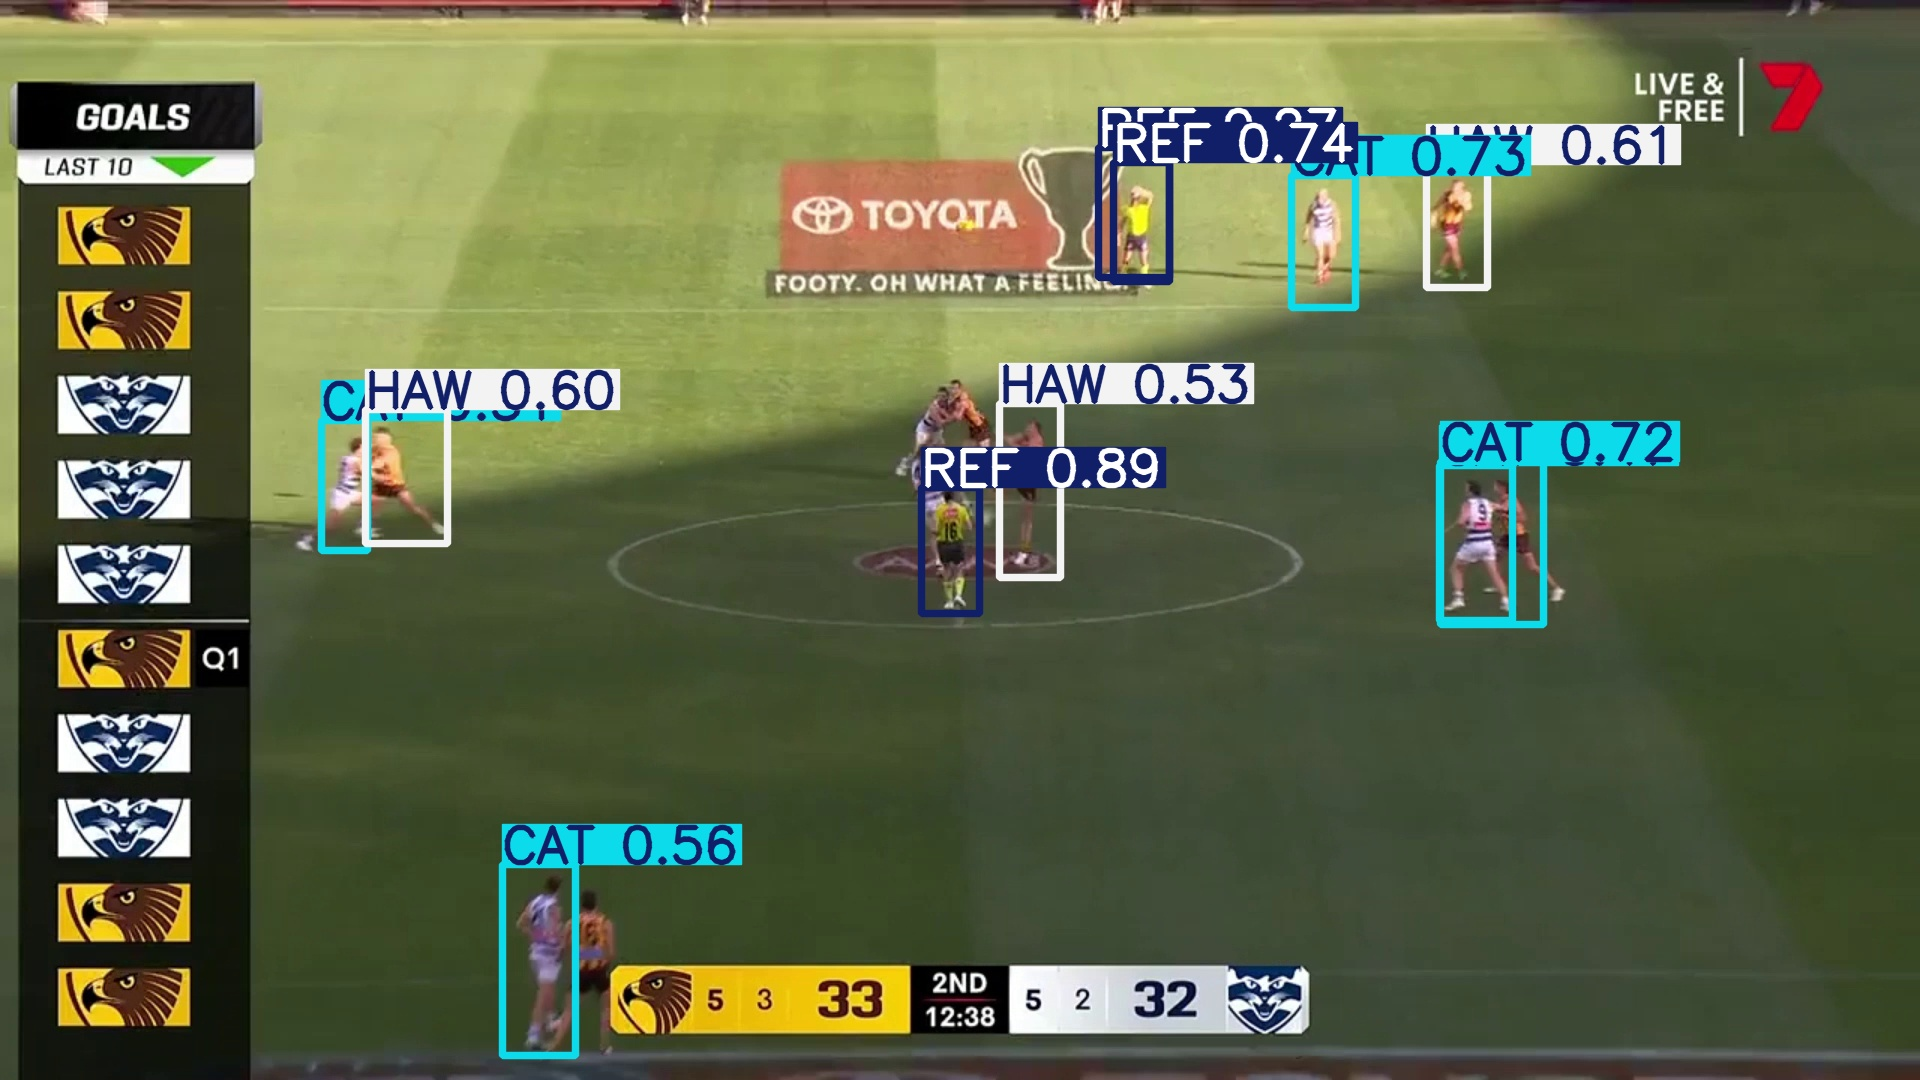

In [16]:
from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display
import random

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

test_images_dir = Path("/content/data_CAT_vs_HAW/yolo_split/images/test")
test_images = list(test_images_dir.glob("*"))

sample_images = random.sample(test_images, min(5, len(test_images)))

results = model.predict(
    source=[str(img) for img in sample_images],
    conf=0.25,
    save=True
)

print("Predictions saved to:", results[0].save_dir)

for img_path in Path(results[0].save_dir).glob("*"):
    display(Image(filename=str(img_path)))

In [17]:
from google.colab import files
from pathlib import Path

best_model = Path("/content/runs/detect/train-2/weights/best.pt")

if best_model.exists():
    files.download(str(best_model))
else:
    print("best.pt not found. Searching...")
    matches = list(Path("/content/runs").rglob("best.pt"))
    print(matches)

    if matches:
        files.download(str(matches[-1]))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>